In [ ]:
# from matplotlib import pyplot as plt
import numpy as np
import os
import random

# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, LSTM

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progrepcss bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# resample signal to n samples
from scipy.signal import resample

# XML parser
import xml.etree.ElementTree as ET

# encoding and normalizing data
from sklearn.preprocessing import LabelEncoder, StandardScaler

: 

In [ ]:
NUM_POINTS = 64 # same as dollar recognizer

## Read Data

In [4]:
data = []

for root, subdirs, files in os.walk('xml_logs'):
    if 'ipynb_checkpoint' in root:
        continue
    
    if len(files) > 0:
        for f in tqdm(files):
            if '.xml' in f:
                fname = f.split('.')[0]
                label = fname[:-2]
                
                xml_root = ET.parse(f'{root}/{f}').getroot()
                
                points = []
                for element in xml_root.findall('Point'):
                    x = element.get('X')
                    y = element.get('Y')
                    points.append([x, y])
                    
                points = np.array(points, dtype=float)
                
                scaler = StandardScaler()
                points = scaler.fit_transform(points)
                
                resampled = resample(points, NUM_POINTS)
                
                data.append((label, resampled))

NameError: name 'tqdm' is not defined

In [4]:
print(data[0])

('arrow', array([[-1.98115675,  1.98053787],
       [-2.06546475,  1.99436522],
       [-1.93086964,  1.8442288 ],
       [-1.90192736,  1.76971743],
       [-1.78875077,  1.71317545],
       [-1.71781591,  1.57516255],
       [-1.57514812,  1.43563976],
       [-1.58042064,  1.39580667],
       [-1.34995696,  1.18830922],
       [-1.19546419,  0.99642441],
       [-0.960359  ,  0.83813815],
       [-0.78288021,  0.61858763],
       [-0.52384061,  0.46002859],
       [-0.32284315,  0.28639652],
       [-0.08225056,  0.0972638 ],
       [ 0.13539409, -0.04098562],
       [ 0.28665714, -0.18479149],
       [ 0.38552463, -0.22181367],
       [ 0.54906291, -0.37553448],
       [ 0.62910992, -0.43764128],
       [ 0.77023395, -0.53465178],
       [ 0.81775568, -0.56226704],
       [ 0.89772108, -0.61428591],
       [ 0.7960657 , -0.65419655],
       [ 0.7157478 , -0.69746153],
       [ 0.5429837 , -0.65135589],
       [ 0.34374538, -0.64974188],
       [ 0.22664267, -0.6529458 ],
       [ 0

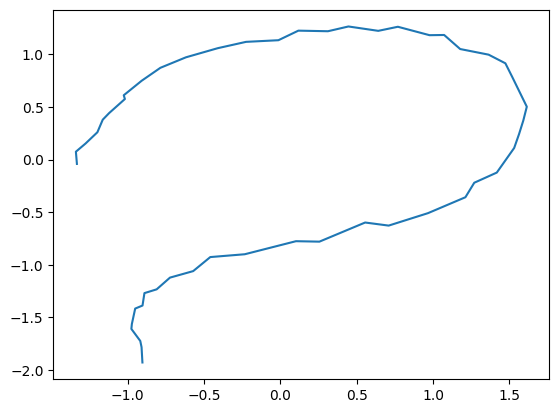

In [13]:
test_data = random.sample(data, 1)[0]

label = test_data[0]
sequence = test_data[1]

plt.plot(sequence.T[0], sequence.T[1]*-1)

## Prepare Data

In [14]:
# Prepare the data
labels = [sample[0] for sample in data]
print("labels: ", set(labels))

# encode (make string-labels numerical)
encoder = LabelEncoder()
labels_encoded = encoder.fit_transform(labels)
print("encoded: ", set(labels_encoded))

# get labels of data
y = to_categorical(labels_encoded)
print("num labels (encoded): ", len(y[0]))

# get point sequences of data
sequences = [sample[1] for sample in data]
X = np.array(sequences)

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

labels:  {'caret', 'delete_mark', 'rectangle', 'arrow', 'right_sq_bracket', 'circle', 'left_sq_bracket', 'pigtail', 'right_curly_brace', 'x', 'star', 'v', 'check', 'question_mark', 'triangle', 'left_curly_brace'}
encoded:  {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)}
num labels (encoded):  16
(4224, 50, 2) (1056, 50, 2) (4224, 16) (1056, 16)


## Define and Train Model 

In [21]:
# Define the model
model = Sequential()

# add LSTM layer
# input shape is (length of an individual sample, dimensions of the sample)
# in our case: two dimensions, as we have X and Y coordinates

# old syntax
#model.add(LSTM(64, input_shape=(NUM_POINTS, 2)))

# new syntax
model.add(Input((NUM_POINTS, 2)))
model.add(LSTM(64))

# add dense layer to do machine learning magic
model.add(Dense(32, activation='relu'))

# here, you can add more layers and maybe a dropout for better performance

# softmax layer for classification
model.add(Dense(len(set(labels)), activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
stop_early = EarlyStopping(monitor='val_loss', patience=3)

In [22]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[reduce_lr, stop_early]
)

Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5611 - loss: 1.5372 - val_accuracy: 0.8731 - val_loss: 0.4540 - learning_rate: 0.0010
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9157 - loss: 0.2839 - val_accuracy: 0.9470 - val_loss: 0.1856 - learning_rate: 0.0010
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9609 - loss: 0.1355 - val_accuracy: 0.9763 - val_loss: 0.0982 - learning_rate: 0.0010
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9725 - loss: 0.0969 - val_accuracy: 0.9744 - val_loss: 0.0862 - learning_rate: 0.0010
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9818 - loss: 0.0702 - val_accuracy: 0.9801 - val_loss: 0.0677 - learning_rate: 0.0010
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9884 - loss: 0.0488 - val_accuracy: 0.9839 - val_loss: 0.0583 - learning_rate: 0.0010
Epoch 7/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9891 - loss: 0.

In [24]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,282 (231.57 KB)

 Trainable params: 19,760 (77.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 39,522 (154.39 KB)

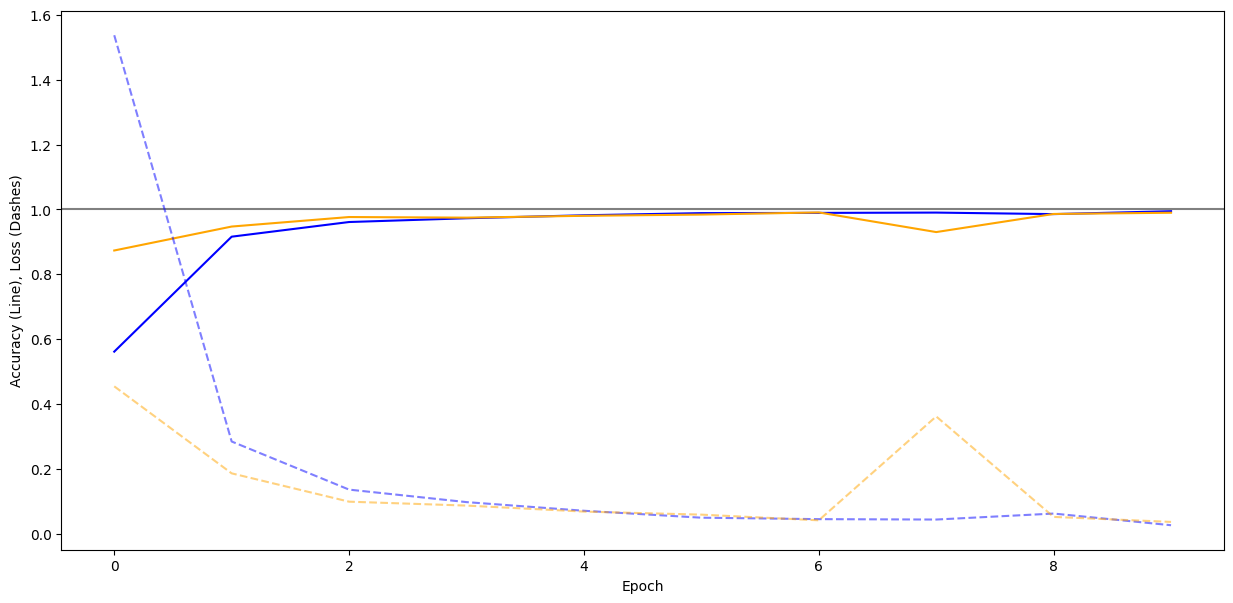

In [25]:
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

fig = plt.figure(figsize=(15, 7))
ax = plt.gca()

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (Line), Loss (Dashes)')

ax.axhline(1, color='gray')

plt.plot(accuracy, color='blue')
plt.plot(val_accuracy, color='orange')
plt.plot(loss, '--', color='blue', alpha=0.5)
plt.plot(val_loss, '--', color='orange', alpha=0.5)

## Predict

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
true label:   caret
prediction:   caret 0.99745923


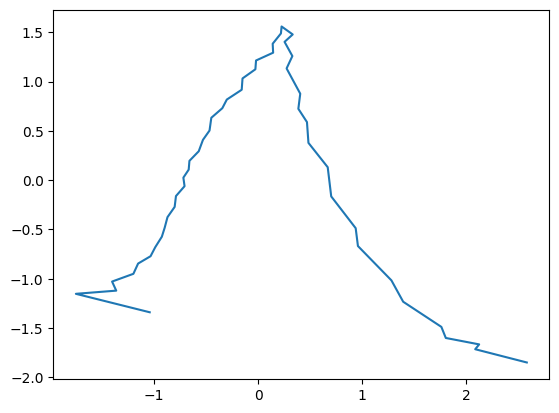

In [26]:
# lets test the model in action

# take random sample of test data and visualize
test_data = random.sample(data, 1)[0]

label = test_data[0]
sequence = test_data[1]

plt.plot(sequence.T[0], sequence.T[1]*-1)

# predict
prediction = model.predict(np.array([sequence]))

prediction_label_encoded = np.argmax(prediction)
prediction_label = encoder.inverse_transform(np.array([prediction_label_encoded]))[0]

print('true label:  ', label)
print('prediction:  ', prediction_label, prediction.max())

In [40]:
# TODO: make predictions for all the samples in test data

y_predictions = model.predict(X_test)

for prediction in y_predictions:
    prediction_label_encoded = np.argmax(prediction)
    prediction_label = encoder.inverse_transform(np.array([prediction_label_encoded]))[0]
    print('prediction:  ', prediction_label, prediction.max())


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
prediction:   arrow 0.99833715
prediction:   v 0.99657553
prediction:   left_sq_bracket 0.98611397
prediction:   question_mark 0.9893484
prediction:   right_curly_brace 0.9974509
prediction:   pigtail 0.9967326
prediction:   delete_mark 0.99886084
prediction:   left_sq_bracket 0.99319565
prediction:   arrow 0.99855334
prediction:   check 0.7565431
prediction:   x 0.9822353
prediction:   v 0.99299556
prediction:   right_sq_bracket 0.99684757
prediction:   triangle 0.96855396
prediction:   check 0.9868038
prediction:   left_curly_brace 0.9968077
prediction:   right_curly_brace 0.9919416
prediction:   check 0.9680503
prediction:   caret 0.99831295
prediction:   v 0.99651283
prediction:   caret 0.99887913
prediction:   x 0.99276054
prediction:   delete_mark 0.9987494
prediction:   v 0.99688524
prediction:   question_mark 0.9980719
prediction:   question_mark 0.9994031
prediction:   delete_mark 0.9988986
prediction:   right_curly_brace 0.99746823
predi

In [ ]:
# TODO: print accuracy of model on test data





In [41]:
# TODO: show confusion matrix
